# Knocking out an induction head

[*Induction heads in the wild*](https://barmag.github.io/) found the hand-crafted circuit inside GPT-2 small and Pythia-160m: a previous-token head (GPT-2 **L4H11**, Pythia **L3H2**) feeding a K-composed induction head (GPT-2 **L5H5**, Pythia **L4H6**), with a copying OV. Every one of those findings was **correlational**. A matrix looked right. A score was high. A rank was 1.

That notebook ended on a promise:

> Knock out L4H11 and L5H5, or L3H2 and L4H6, and watch whether the induction score collapses. That is the next notebook.

This is that notebook. We cut heads out of the forward pass and watch what breaks.

**Hypotheses.**

1. **H1 (knock-out).** If L5H5 / L4H6 *is* the induction head, removing it should collapse induction behavior — the model should lose its ability to predict the repeated half of a repeated random sequence. Predicted wrinkle: only a *partial* collapse, because the wild notebook already showed the behavior lives in a small cluster (GPT-2's L6H9 scores 0.917 against L5H5's 0.930).
2. **H2 (mediation).** If K-composition is causal, removing the *previous-token* head should kill the *induction* head's attention stripe — an effect one layer removed from the intervention.
3. **H3 (stretch).** If Pythia L4H6's negative OV eigenvalue mass is non-copying work sharing the same head, surgically removing those directions should preserve induction while costing something elsewhere.

**Papers.** Olsson et al. 2022, [*In-context Learning and Induction Heads*](https://transformer-circuits.pub/2022/in-context-learning-and-induction-heads/index.html) (ablations, per-token induction loss); Wang et al. 2023, [*Interpretability in the Wild*](https://arxiv.org/abs/2211.00593) (backup heads — the hydra effect); Elhage et al. 2021, [*A Mathematical Framework for Transformer Circuits*](https://transformer-circuits.pub/2021/framework/index.html) (OV eigenvalues).


In [1]:
import os
os.environ.setdefault("HSA_OVERRIDE_GFX_VERSION", "11.0.0")  # Strix Halo gfx1151 runs the gfx1100 wheels

import subprocess
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import torch
from transformer_lens import HookedTransformer, utils

SEED = 42
torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
commit = subprocess.run(["git", "rev-parse", "--short", "HEAD"], capture_output=True, text=True).stdout.strip()
print(f"device={device}  seed={SEED}  commit={commit}")
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

device=cuda  seed=42  commit=6bf9a5a
GPU: AMD Radeon 8060S Graphics


## Act 0 — The yardstick

Olsson et al. measure induction with a **repeated random sequence**: sample a block of random tokens, concatenate it with itself, and ask the model to predict. The first copy is unpredictable by construction — random tokens carry no signal, so the model can do no better than its prior. The second copy is perfectly predictable *if and only if* the model can look back, find where the current token appeared before, and copy what followed.

So the difference between those two halves is the behavior itself, measured in nats:

> **induction loss gap** = mean loss on the first (unrepeated) half − mean loss on the second (repeated) half.

Positive by construction when induction works. Every intervention in this notebook is scored by how much of this gap it destroys:

> **collapse fraction** = (gap_clean − gap_ablated) / gap_clean

0% means the intervention did nothing. 100% means induction is gone.

Both models, same seed and batch as the previous notebook, so the numbers line up across the two.

In [2]:
gpt2 = HookedTransformer.from_pretrained("gpt2", device=device)
pythia = HookedTransformer.from_pretrained("pythia-160m", device=device)
MODELS = {"gpt2": gpt2, "pythia": pythia}

BATCH, T, GATE = 32, 50, 0.2


def repeated_tokens(model, batch=BATCH, block=T, seed=SEED):
    """[BOS, block, block] -> [batch, 2T+1]. Same generator and seed as the previous notebook."""
    g = torch.Generator().manual_seed(seed)
    block_toks = torch.randint(100, 50_000, (batch, block), generator=g)  # both vocabs exceed 50k
    bos = torch.full((batch, 1), model.tokenizer.bos_token_id, dtype=torch.long)
    return torch.cat([bos, block_toks, block_toks], dim=1).to(model.cfg.device)


def halves(lpt):
    """loss_per_token[:, i] scores predicting token i+1. Cols 0..T-1 = first copy, T..2T-1 = second."""
    return lpt[:, 0:T].mean().item(), lpt[:, T:2 * T].mean().item()


def loss_gap(lpt):
    first, second = halves(lpt)
    return first - second


TOKENS, BASE = {}, {}
for name, model in MODELS.items():
    TOKENS[name] = repeated_tokens(model)
    lpt = model(TOKENS[name], return_type="loss", loss_per_token=True)
    first, second = halves(lpt)
    BASE[name] = {"first": first, "second": second, "gap": first - second}
    print(f"{name}: first(unrepeated)={first:6.3f}  second(repeated)={second:5.3f}  "
          f"gap={first - second:6.3f} nats")


def collapse(gap_abl, name):
    return (BASE[name]["gap"] - gap_abl) / BASE[name]["gap"]

`torch_dtype` is deprecated! Use `dtype` instead!


/home/yassermakram/code/fanous-llm-lens/.venv/lib64/python3.11/site-packages/torch/nn/modules/module.py:1326: UserWarning: expandable_segments not supported on this platform (Triggered internally at ../c10/hip/HIPAllocatorConfig.h:29.)
  return t.to(


Loaded pretrained model gpt2 into HookedTransformer


Loaded pretrained model pythia-160m into HookedTransformer


/home/yassermakram/code/fanous-llm-lens/.venv/lib64/python3.11/site-packages/transformer_lens/utilities/attention.py:27: UserWarning: Attempting to use hipBLASLt on an unsupported architecture! Overriding blas backend to hipblas (Triggered internally at ../aten/src/ATen/Context.cpp:296.)
  return F.linear(input, w, b_).reshape(input.shape[0], input.shape[1], b.shape[0], b.shape[1])


gpt2: first(unrepeated)=13.190  second(repeated)=0.481  gap=12.709 nats


pythia: first(unrepeated)=23.443  second(repeated)=5.561  gap=17.881 nats


### Results — the gap is real, and the two models are not alike

**GPT-2 small:** 13.190 nats on the unrepeated half, **0.481** on the repeated half — a gap of **12.709 nats**. The second time it sees the sequence, GPT-2 predicts it at about half a nat per token. That is very close to knowing the answer.

**Pythia-160m:** 23.443 → **5.561**, a gap of **17.881 nats**. The gap is *larger*, but read the second number rather than the difference: Pythia still pays 5.6 nats per token on text it has already seen once. It is copying, but nothing like as cleanly as GPT-2 — despite Pythia's induction head scoring *higher* on the attention diagnostic in the previous notebook (0.987 vs 0.930). Attending to the right place and writing the right token are two different jobs, and the previous notebook already saw the seam: Pythia's copying-OV score was 0.423 against GPT-2's 0.816.

Both first-half losses sit above ln(50000) ≈ 10.8 nats, the cost of guessing uniformly among the token IDs we sampled from. That is expected: a language model is not a uniform prior over token IDs. It finds a random draw from the middle of the vocabulary *less* likely than chance would, and Pythia — whose tokenizer and training mix differ from GPT-2's — finds it much less likely still. This is why the two models' absolute nats are not comparable to each other, and why every intervention below is scored as a **fraction of that model's own gap** rather than in raw nats.

The gap is the yardstick. Now we start cutting.

## Act 1 — Calibrate the scalpel

To remove a head we replace its output with something else. The naive choice is **zero**: set the head's `hook_z` (its per-head output, before `W_O`) to 0. But zero is not a neutral value. A trained network never sees a head output zero; the rest of the model has no idea what to do with it. Zeroing takes the model **off-distribution**, and then any damage you measure is partly the damage of feeding the model an input it was never built for — not the loss of the head's job.

The standard fix, and what the interpretability literature settled on: **mean-ablation**. Replace the head's output with its *average* output over a reference distribution. The head stops carrying information about *this particular sequence*, but the downstream layers still receive a vector of the size and shape they expect. What you subtract is the head's signal, not its existence.

We show both, once, on GPT-2's L5H5 — then use mean-ablation everywhere after.

In [3]:
def z_means(model, ref_tokens):
    """Per-head mean hook_z over batch and position: {layer: [n_heads, d_head]}."""
    _, cache = model.run_with_cache(
        ref_tokens, return_type=None, names_filter=lambda n: n.endswith("hook_z")
    )
    return {l: cache["z", l].mean(dim=(0, 1)) for l in range(model.cfg.n_layers)}


# Reference batch: same distribution as the eval batch, disjoint draw.
ZM = {name: z_means(m, repeated_tokens(m, seed=SEED + 1000)) for name, m in MODELS.items()}


def ablation_hooks(targets, zm):
    """targets: [(layer, head), ...] -> TransformerLens fwd_hooks replacing each head's z."""
    by_layer = defaultdict(list)
    for layer, head in targets:
        by_layer[layer].append(head)

    def make(heads, layer):
        def hook(z, hook):          # z: [batch, pos, head, d_head]
            for h in heads:
                z[:, :, h, :] = zm[layer][h]
            return z
        return hook

    return [(utils.get_act_name("z", l), make(hs, l)) for l, hs in by_layer.items()]


def run_ablated(model, tokens, targets, zm, names_filter=None):
    hooks = ablation_hooks(targets, zm)
    if names_filter is None:
        return model.run_with_hooks(tokens, return_type="loss", loss_per_token=True, fwd_hooks=hooks)
    with model.hooks(fwd_hooks=hooks):
        return model.run_with_cache(tokens, return_type=None, names_filter=names_filter)


IND = {"gpt2": (5, 5), "pythia": (4, 6)}      # induction heads, from the previous notebook
PREV = {"gpt2": (4, 11), "pythia": (3, 2)}    # previous-token heads

ZERO = {name: {l: torch.zeros_like(v) for l, v in zm.items()} for name, zm in ZM.items()}

CALIB = {}
for kind, ref in [("mean", ZM), ("zero", ZERO)]:
    lpt = run_ablated(gpt2, TOKENS["gpt2"], [IND["gpt2"]], ref["gpt2"])
    CALIB[kind] = collapse(loss_gap(lpt), "gpt2")
    print(f"GPT-2 L5H5 {kind}-ablated: gap={loss_gap(lpt):6.3f}  "
          f"collapse={CALIB[kind]:5.1%}  (clean gap {BASE['gpt2']['gap']:.3f})")

GPT-2 L5H5 mean-ablated: gap=12.621  collapse= 0.7%  (clean gap 12.709)
GPT-2 L5H5 zero-ablated: gap=12.694  collapse= 0.1%  (clean gap 12.709)


### Results — the scalpel is calibrated, and it cuts nothing

Mean-ablating L5H5 destroys **0.7%** of the induction gap (12.709 → 12.621). Zero-ablating it destroys **0.1%** (12.709 → 12.694).

Two things to take from this, and it matters which is which.

**The methodological point stands.** Mean-ablation is the right default and we use it for the rest of the notebook: it removes a head's information without handing the downstream layers a vector they have never seen. Nothing below depends on the choice, but the reasoning is load-bearing whenever an ablation *does* bite.

**The honest point is that here, neither tool bites at all.** The interesting number is not the difference between 0.7% and 0.1% — both are, to a first approximation, zero. We just deleted the head that the previous notebook identified as GPT-2's induction head, the one scoring 0.930 on the induction diagnostic, and the model's ability to exploit a repeated sequence is **essentially untouched**. It still predicts the repeated half at 0.5 nats per token.

That is not a defect of the scalpel. It is the first real finding, and Act 2 is about taking it seriously.

## Act 2a — Knock out the induction head

Olsson et al. establish induction heads causally by ablating them and watching in-context learning degrade. So: mean-ablate the single best induction head each model has — GPT-2's L5H5 (score 0.930), Pythia's L4H6 (0.987) — and measure how much of the loss gap dies with it.

If "the induction head" is *the* induction head, this is where the behavior collapses.

In [4]:
def ind_scores(cache, model):
    """Induction attention score per head: mass at offset -(T-1), same definition as before."""
    q = torch.arange(T + 1, 2 * T + 1)
    out = torch.zeros(model.cfg.n_layers, model.cfg.n_heads)
    for layer in range(model.cfg.n_layers):
        out[layer] = cache["pattern", layer][:, :, q, q - T + 1].mean(dim=(0, 2)).cpu()
    return out


SCORES, LADDER = {}, {}
for name, model in MODELS.items():
    _, cache = model.run_with_cache(
        TOKENS[name], return_type=None, names_filter=lambda n: n.endswith("pattern")
    )
    SCORES[name] = ind_scores(cache, model)
    del cache
    lpt = run_ablated(model, TOKENS[name], [IND[name]], ZM[name])
    LADDER[name] = {"top-1": collapse(loss_gap(lpt), name)}
    l, h = IND[name]
    print(f"{name}: ablate L{l}H{h} (score {SCORES[name][l, h]:.3f})  "
          f"gap {BASE[name]['gap']:6.3f} -> {loss_gap(lpt):6.3f}   "
          f"collapse={LADDER[name]['top-1']:5.1%}")

gpt2: ablate L5H5 (score 0.930)  gap 12.709 -> 12.621   collapse= 0.7%


pythia: ablate L4H6 (score 0.987)  gap 17.881 -> 17.015   collapse= 4.8%


### Act 2b — The hydra check

Nothing collapsed. Before concluding the head does nothing, consider what *Interpretability in the Wild* found when it ablated GPT-2's name-mover heads: other heads **took over**. Wang et al. call them backup heads — heads that sit quiet in the clean model and step into the job when the primary is removed. Cut off one head, two grow back.

The previous notebook already flagged the suspects: L6H9 scores 0.917 on induction against L5H5's 0.930. That is not a runner-up, it is a twin.

So re-measure *every* head's induction score inside the ablated forward pass and compare to clean. If the runners-up strengthen, the circuit is a hydra and single-head ablation was never going to work.

gpt2: heads that strengthen most under L5H5 ablation
    L6H9: 0.917 -> 0.963 (+0.046)
    L7H11: 0.042 -> 0.069 (+0.027)
    L10H7: 0.473 -> 0.493 (+0.020)


pythia: heads that strengthen most under L4H6 ablation
    L8H10: 0.066 -> 0.092 (+0.026)
    L6H11: 0.045 -> 0.070 (+0.025)
    L5H0: 0.807 -> 0.823 (+0.017)


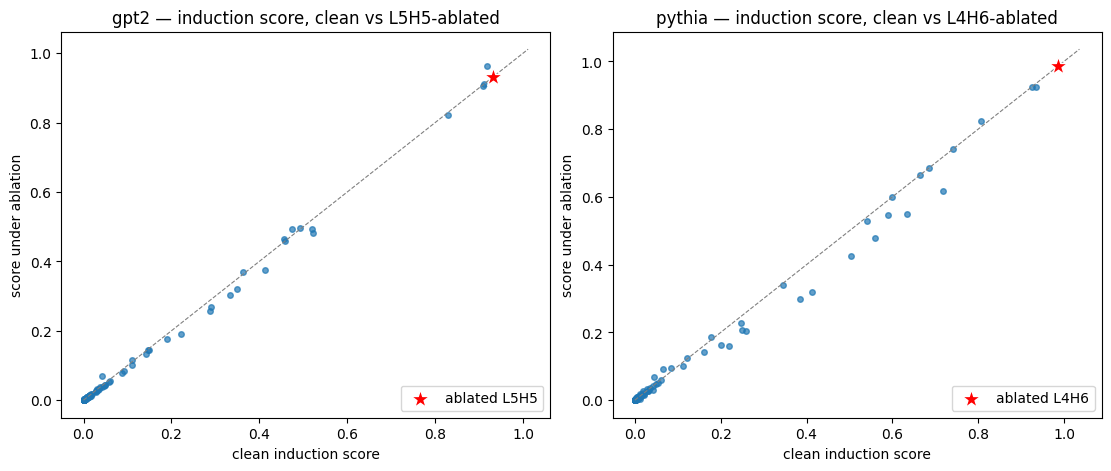

In [5]:
HYDRA = {}
for name, model in MODELS.items():
    _, cache = run_ablated(
        model, TOKENS[name], [IND[name]], ZM[name],
        names_filter=lambda n: n.endswith("pattern"),
    )
    HYDRA[name] = ind_scores(cache, model)
    del cache
    l, h = IND[name]
    delta = HYDRA[name] - SCORES[name]
    delta[l, h] = 0.0                       # the ablated head itself is not a backup
    flat = delta.flatten().argsort(descending=True)[:3]
    print(f"{name}: heads that strengthen most under L{l}H{h} ablation")
    for f in flat:
        ll, hh = divmod(f.item(), model.cfg.n_heads)
        print(f"    L{ll}H{hh}: {SCORES[name][ll, hh]:.3f} -> {HYDRA[name][ll, hh]:.3f} "
              f"({delta[ll, hh]:+.3f})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
for ax, (name, model) in zip(axes, MODELS.items()):
    x, y = SCORES[name].flatten(), HYDRA[name].flatten()
    ax.scatter(x, y, s=16, alpha=0.7)
    lims = [0, max(x.max().item(), y.max().item()) * 1.05]
    ax.plot(lims, lims, color="grey", lw=0.8, ls="--")
    l, h = IND[name]
    ax.scatter([SCORES[name][l, h]], [HYDRA[name][l, h]], marker="*", s=200, c="red",
               edgecolors="white", zorder=3, label=f"ablated L{l}H{h}")
    ax.set_title(f"{name} — induction score, clean vs L{l}H{h}-ablated")
    ax.set_xlabel("clean induction score")
    ax.set_ylabel("score under ablation")
    ax.legend(loc="lower right")
plt.show()

### Act 2c — Escalate

If one head is not the circuit, how many are? Take every head whose clean induction score clears 0.2 — the previous notebook's gate — and remove the whole set at once. Between the two, an intermediate rung: the top 3 heads by score.

This is the escalation ladder: one head, three heads, the whole cluster. Where the gap finally falls is a measurement of how distributed the behavior is.

gpt2: ablate top-3    (n= 3)  gap -> 10.072  collapse=20.7%
gpt2: ablate cluster  (n=18)  gap ->  2.266  collapse=82.2%
    gpt2 cluster: L5H0(0.46), L5H1(0.91), L5H5(0.93), L6H9(0.92), L7H1(0.22), L7H2(0.83), L7H10(0.91), L8H1(0.36), L9H0(0.29), L9H6(0.52), L9H9(0.49), L10H0(0.41), L10H1(0.52), L10H6(0.33), L10H7(0.47), L10H11(0.29), L11H9(0.35), L11H10(0.46)


pythia: ablate top-3    (n= 3)  gap -> 16.232  collapse= 9.2%
pythia: ablate cluster  (n=22)  gap ->  2.448  collapse=86.3%
    pythia cluster: L4H6(0.99), L4H8(0.66), L4H10(0.92), L4H11(0.68), L5H0(0.81), L5H6(0.74), L5H7(0.60), L8H2(0.93), L8H8(0.59), L8H11(0.54), L9H2(0.50), L9H4(0.25), L9H5(0.25), L9H6(0.56), L9H7(0.35), L9H8(0.72), L9H9(0.63), L10H6(0.41), L10H7(0.22), L10H8(0.26), L10H10(0.38), L10H11(0.20)


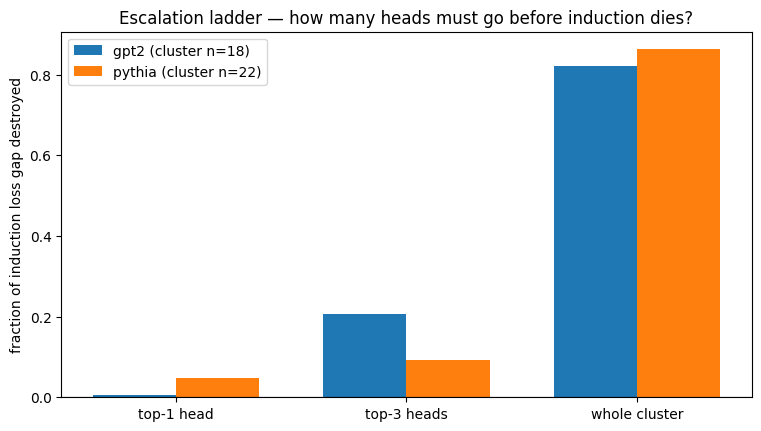

In [6]:
CLUSTER, TOP3 = {}, {}
for name, model in MODELS.items():
    n_heads = model.cfg.n_heads
    CLUSTER[name] = [(l, h) for l in range(model.cfg.n_layers) for h in range(n_heads)
                     if SCORES[name][l, h] > GATE]
    TOP3[name] = [divmod(f.item(), n_heads)
                  for f in SCORES[name].flatten().argsort(descending=True)[:3]]
    for label, targets in [("top-3", TOP3[name]), ("cluster", CLUSTER[name])]:
        lpt = run_ablated(model, TOKENS[name], targets, ZM[name])
        LADDER[name][label] = collapse(loss_gap(lpt), name)
        print(f"{name}: ablate {label:8s} (n={len(targets):2d})  gap -> {loss_gap(lpt):6.3f}  "
              f"collapse={LADDER[name][label]:5.1%}")
    print(f"    {name} cluster: " + ", ".join(f"L{l}H{h}({SCORES[name][l, h]:.2f})"
                                              for l, h in CLUSTER[name]))

fig, ax = plt.subplots(figsize=(7.5, 4.2), constrained_layout=True)
rungs = ["top-1", "top-3", "cluster"]
width = 0.36
for i, name in enumerate(MODELS):
    ax.bar([r + (i - 0.5) * width for r in range(len(rungs))],
           [LADDER[name][r] for r in rungs], width,
           label=f"{name} (cluster n={len(CLUSTER[name])})")
ax.set_xticks(range(len(rungs)))
ax.set_xticklabels(["top-1 head", "top-3 heads", "whole cluster"])
ax.set_ylabel("fraction of induction loss gap destroyed")
ax.set_title("Escalation ladder — how many heads must go before induction dies?")
ax.axhline(0, color="black", lw=0.8)
ax.legend()
plt.show()

### Results — Act 2

**The single head is not the circuit.** Ablating GPT-2's L5H5 destroys **0.7%** of the induction gap; ablating Pythia's L4H6 destroys **4.8%**. These are the heads the previous notebook identified by argmax, matching the heads Wang et al. name in print, scoring 0.930 and 0.987 on the induction diagnostic. Removing them entirely costs the models almost nothing.

**The hydra is real in GPT-2, and thinner than advertised.** Under L5H5 ablation, its twin **L6H9 rises 0.917 → 0.963** — the largest movement in the grid, and exactly the backup behavior Wang et al. describe: a head that steps up when the primary is cut. But notice the *size* of the step. L6H9 gains 0.046. It does not double. It was already doing the job at 0.917 before we touched anything.

Pythia shows no comparable twin at all: its biggest movers are L8H10 (0.066 → 0.092) and L6H11 (0.045 → 0.070), heads that barely do induction in the first place, and its strongest sibling L5H0 shifts only 0.807 → 0.823.

So "backup heads compensate" is the smaller half of the explanation. The larger half is that **there was never anything to compensate for**: the job was already spread across a dozen heads before the intervention. GPT-2 has 18 heads above the 0.2 gate; Pythia has 22. Cutting one of eighteen is not a lesion, it is a rounding error.

**The ladder shows how spread.** Three heads — the best induction heads each model has, all scoring ≥0.9 — buy only **20.7%** (GPT-2) and **9.2%** (Pythia). The behavior does not collapse until the whole above-gate cluster goes: **82.2%** with 18 heads (GPT-2), **86.3%** with 22 (Pythia).

That is the answer to H1, and it is the opposite of the clean story. Induction is not a head. It is a *population*, and the population is deeply redundant — 18 heads to destroy a behavior that any one of them appears, by attention score, to be performing almost completely on its own.

**The honest caveat, and what Act 4 does about it.** Ablating 18 of 144 heads (a quarter of layers 5–11) is a large lesion. An 82% collapse is *consistent with* "we removed induction", but it is equally consistent with "we broke the second half of the network." Nothing in this act separates the two. Act 4 is the control: if what we removed is induction-specific, the damage on real text should land on the positions where induction can act, and nowhere else.

## Act 3 — Knock out the feeder

The previous notebook's cleanest finding was **K-composition**: of all 60 heads that could feed GPT-2's L5H5 key, the previous-token head L4H11 ranked **first** (0.097); for Pythia's L4H6, L3H2 ranked first of 48 (0.147). That is a weight-space claim — the wiring *looks* right.

Here is its causal test. Ablate **only the previous-token head** and read out the *induction* head's attention. The induction head itself is untouched. Its query, its key, its value, its output projection are all exactly as they were. If its stripe to matched positions collapses anyway, then what it was keying on was the previous-token head's output — cause, one layer downstream of the cut.

This is also a fairer test of a single-head ablation than Act 2: the previous-token head has no twin sitting at 0.917.

gpt2: ablate prev-token L4H11 -> induction head L5H5 stripe 0.930 -> 0.638 (31.5% gone);  model loss gap 12.709 -> 12.414 (collapse 2.3%)


pythia: ablate prev-token L3H2 -> induction head L4H6 stripe 0.987 -> 0.159 (83.9% gone);  model loss gap 17.881 -> 10.028 (collapse 43.9%)


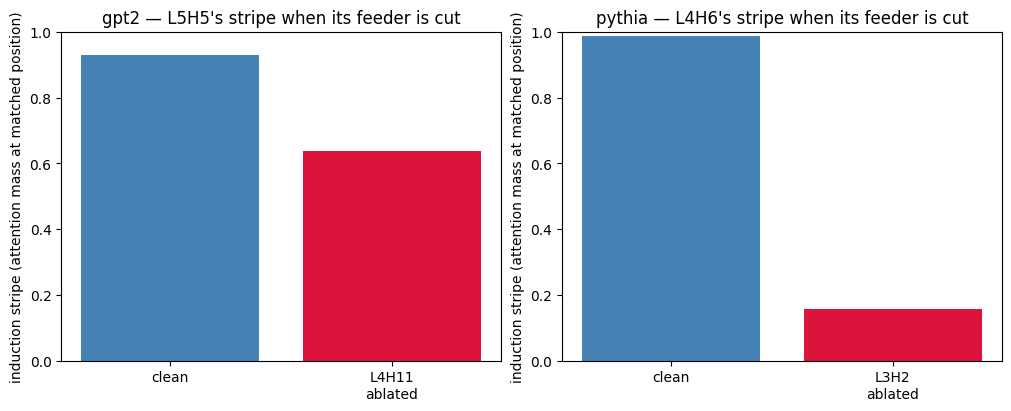

In [7]:
MED = {}
for name, model in MODELS.items():
    li, hi = IND[name]
    lp, hp = PREV[name]
    q = torch.arange(T + 1, 2 * T + 1)

    _, clean_cache = model.run_with_cache(
        TOKENS[name], return_type=None, names_filter=utils.get_act_name("pattern", li)
    )
    stripe_clean = clean_cache["pattern", li][:, hi, q, q - T + 1].mean().item()
    del clean_cache

    _, abl_cache = run_ablated(
        model, TOKENS[name], [PREV[name]], ZM[name],
        names_filter=utils.get_act_name("pattern", li),
    )
    stripe_abl = abl_cache["pattern", li][:, hi, q, q - T + 1].mean().item()
    del abl_cache

    lpt = run_ablated(model, TOKENS[name], [PREV[name]], ZM[name])
    MED[name] = {
        "stripe_clean": stripe_clean, "stripe_abl": stripe_abl,
        "gap_abl": loss_gap(lpt), "collapse": collapse(loss_gap(lpt), name),
    }
    print(f"{name}: ablate prev-token L{lp}H{hp} -> induction head L{li}H{hi} stripe "
          f"{stripe_clean:.3f} -> {stripe_abl:.3f} "
          f"({(stripe_clean - stripe_abl) / stripe_clean:.1%} gone);  "
          f"model loss gap {BASE[name]['gap']:.3f} -> {MED[name]['gap_abl']:.3f} "
          f"(collapse {MED[name]['collapse']:.1%})")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for ax, name in zip(axes, MODELS):
    li, hi = IND[name]
    lp, hp = PREV[name]
    ax.bar(["clean", f"L{lp}H{hp}\nablated"],
           [MED[name]["stripe_clean"], MED[name]["stripe_abl"]],
           color=["steelblue", "crimson"])
    ax.set_ylim(0, 1)
    ax.set_ylabel("induction stripe (attention mass at matched position)")
    ax.set_title(f"{name} — L{li}H{hi}'s stripe when its feeder is cut")
plt.show()

### Results — Act 3

**K-composition is causal.** In both models, cutting the previous-token head degrades the induction head's attention without touching the induction head at all:

- GPT-2: L5H5's stripe **0.930 → 0.638** (31.5% gone) when L4H11 is ablated.
- Pythia: L4H6's stripe **0.987 → 0.159** (83.9% gone) when L3H2 is ablated.

The previous notebook's rank-1 finding was not an artefact of reading matrices. The previous-token head's output really is what the induction head keys on. Remove it and the induction head, structurally untouched, stops finding the matched position.

**And the feeder matters far more than the head it feeds.** Compare the model-level numbers to Act 2:

| intervention | GPT-2 | Pythia |
|---|---|---|
| ablate the *induction* head | 0.7% | 4.8% |
| ablate the *previous-token* head | **2.3%** | **43.9%** |

For Pythia, cutting one previous-token head destroys **nine times** more induction behavior than cutting the induction head itself. The head that gets the name is not the head that carries the risk.

**Why: redundancy, not importance.** This is the same lesson as Act 2 read from the other end. Pythia's L3H2 has no twin — nothing else in the model does the previous-token job, so removing it starves all 22 downstream induction heads at once. One cut, upstream, achieves what 22 simultaneous cuts achieved downstream. GPT-2 degrades far more gently (31.5% of the stripe, 2.3% of the behavior) because its previous-token job *is* backed up: the previous notebook clocked L2H2 at 0.485 on the same diagnostic, a second source that keeps feeding L5H5's key when L4H11 goes.

So ablation magnitude measures **how redundant a component is**, not how important it is. A head can be doing essential work and show a 0.7% ablation effect, purely because seventeen other heads are doing it too. This is the trap the whole notebook is built around: *"ablate it and see if it matters"* silently asks a different question than the one you meant.

**Partial, not total.** Neither stripe falls to zero — GPT-2 keeps 0.638, Pythia keeps 0.159. Other heads also feed the key, so the previous-token head is a major source but never the sole one. And a stripe is attention, not output: Act 4 asks what this costs in logits.

## Act 4 — Does any of this matter on real text?

Repeated random tokens are a laboratory instrument: they isolate induction by making it the *only* usable strategy. Real text is not like that. A model predicting English has grammar, frequency, and semantics to lean on — induction is one contributor among many.

Olsson et al. make this move too, measuring per-token loss on natural text rather than only on synthetic sequences. So: ablate the whole induction cluster and measure the per-token loss increase on Pile text, split two ways —

- positions where the bigram ending here **has already appeared** in this document (induction has something to copy), versus
- **everywhere else** (it does not).

This is the control Act 2 needs. An 82% collapse from removing 18 heads is consistent with "we removed induction" *and* with "we broke a quarter of the network." If the cluster is doing induction rather than generic work, the damage must concentrate on the first group. If it lands evenly, Act 2's number means much less than it looks.

Reference means are recomputed **on natural text** here — mean-ablation is only on-distribution with respect to the distribution the means came from, and the synthetic means from Act 1 describe a world of uniform random tokens.

In [8]:
import os

# Pile cache, relative to this notebook (shared with icl_from_scratch.ipynb)
CORPUS = "checkpoints/icl_pile/corpus.txt"
N_DOCS, N_CTX = 8, 256

if os.path.exists(CORPUS):
    with open(CORPUS, encoding="utf-8") as f:
        raw = f.read(2_000_000)
    print(f"[corpus] cache hit: {len(raw):,} chars from {CORPUS}")
else:
    from datasets import load_dataset

    stream = load_dataset("monology/pile-uncopyrighted", split="train", streaming=True)
    parts, total = [], 0
    for row in stream:
        parts.append(row["text"])
        total += len(row["text"]) + 1
        if total >= 2_000_000:
            break
    raw = "\n".join(parts)
    os.makedirs(os.path.dirname(CORPUS), exist_ok=True)
    with open(CORPUS, "w", encoding="utf-8") as f:
        f.write(raw)
    print(f"[corpus] streamed + cached {len(raw):,} chars -> {CORPUS}")

docs = [d for d in raw.split("\n") if len(d) > 2000][:N_DOCS]
print(f"[corpus] {len(docs)} documents; first 100 chars: {docs[0][:100]!r}")


def repeated_bigram_mask(tokens):
    """mask[b, i] = True if bigram (tok[i-1], tok[i]) already appeared -> induction can act."""
    b, n = tokens.shape
    mask = torch.zeros(b, n - 1, dtype=torch.bool)
    for bi in range(b):
        seen, seq = set(), tokens[bi].tolist()
        for i in range(1, n - 1):
            key = (seq[i - 1], seq[i])
            if key in seen:
                mask[bi, i] = True
            seen.add(key)
    return mask


NAT, BIGRAM, ZM_NAT = {}, {}, {}
for name, model in MODELS.items():
    NAT[name] = model.to_tokens(docs)[:, :N_CTX]
    BIGRAM[name] = repeated_bigram_mask(NAT[name])
    ZM_NAT[name] = z_means(model, NAT[name])
    print(f"{name}: natural batch {tuple(NAT[name].shape)}, "
          f"{BIGRAM[name].float().mean():.1%} of positions are repeated bigrams")

[corpus] cache hit: 2,000,000 chars from checkpoints/icl_pile/corpus.txt
[corpus] 8 documents; first 100 chars: 'Autosomal dominant polycystic kidney disease (ADPKD) is a common monoallelic disorder associated wit'
gpt2: natural batch (8, 256), 20.8% of positions are repeated bigrams
pythia: natural batch (8, 256), 19.8% of positions are repeated bigrams


gpt2: clean natural loss 3.360 nats;  cluster-ablation delta: repeated-bigram +1.238  elsewhere +0.179  (ratio 6.9x)


pythia: clean natural loss 2.741 nats;  cluster-ablation delta: repeated-bigram +0.607  elsewhere +0.169  (ratio 3.6x)


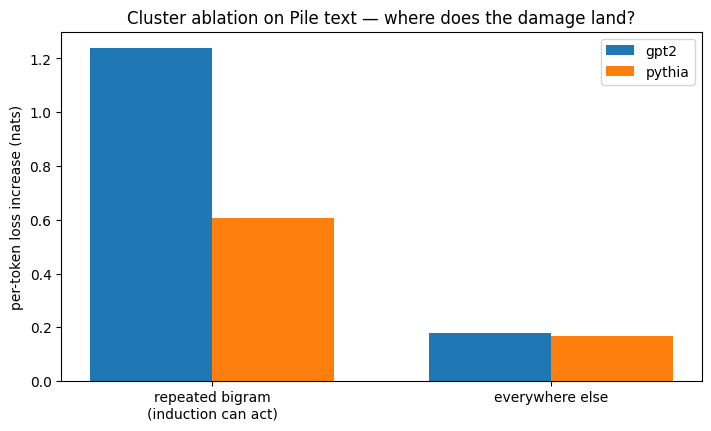

In [9]:
NATDELTA = {}
for name, model in MODELS.items():
    clean = model(NAT[name], return_type="loss", loss_per_token=True).cpu()
    abl = run_ablated(model, NAT[name], CLUSTER[name], ZM_NAT[name]).cpu()
    d = abl - clean
    m = BIGRAM[name]
    NATDELTA[name] = {
        "clean": clean.mean().item(),
        "repeated": d[m].mean().item(),
        "elsewhere": d[~m].mean().item(),
    }
    print(f"{name}: clean natural loss {NATDELTA[name]['clean']:.3f} nats;  "
          f"cluster-ablation delta: repeated-bigram {NATDELTA[name]['repeated']:+.3f}  "
          f"elsewhere {NATDELTA[name]['elsewhere']:+.3f}  "
          f"(ratio {NATDELTA[name]['repeated'] / NATDELTA[name]['elsewhere']:.1f}x)")

fig, ax = plt.subplots(figsize=(7, 4.2), constrained_layout=True)
width = 0.36
for i, name in enumerate(MODELS):
    ax.bar([x + (i - 0.5) * width for x in range(2)],
           [NATDELTA[name]["repeated"], NATDELTA[name]["elsewhere"]], width, label=name)
ax.set_xticks(range(2))
ax.set_xticklabels(["repeated bigram\n(induction can act)", "everywhere else"])
ax.set_ylabel("per-token loss increase (nats)")
ax.set_title("Cluster ablation on Pile text — where does the damage land?")
ax.legend()
plt.show()

### The same cut, measured in logits

Attention says where a head looks. It does not say what the head *writes*. One compact direct-logit-attribution beat closes that gap: take the induction head's output at each second-copy position, project it through the unembedding `W_U` onto the token it is supposed to be copying, and read off how many logits the head contributes to the right answer.

Then cut its feeder (Act 3's intervention) and measure again. If K-composition is what lets the head find the matched token, cutting the feeder should cost the head its push on the correct logit — not just its attention.

In [10]:
def dla_matched(model, name, fwd_hooks=()):
    """Matched-token logit contribution of the induction head: W_U-projection of its output.

    LayerNorm's final scale is not applied — this is the head's raw write into the logits.
    """
    l, h = IND[name]
    with model.hooks(fwd_hooks=list(fwd_hooks)):
        _, cache = model.run_with_cache(
            TOKENS[name], return_type=None, names_filter=utils.get_act_name("z", l)
        )
    out = cache["z", l][:, :, h, :] @ model.W_O[l, h]     # [batch, pos, d_model]
    qs = torch.arange(T + 1, 2 * T)                       # second-copy queries with a next token
    tgt = TOKENS[name][:, qs + 1]                         # the token induction should copy
    w = model.W_U[:, tgt]                                 # [d_model, batch, Q]
    return (out[:, qs, :] * w.permute(1, 2, 0)).sum(-1).mean().item()


DLA = {}
for name, model in MODELS.items():
    DLA[name] = {
        "clean": dla_matched(model, name),
        "feeder_ablated": dla_matched(model, name, ablation_hooks([PREV[name]], ZM[name])),
    }
    li, hi = IND[name]
    lp, hp = PREV[name]
    print(f"{name}: L{li}H{hi} matched-token logit contribution  clean {DLA[name]['clean']:+.3f}"
          f"  ->  L{lp}H{hp}-ablated {DLA[name]['feeder_ablated']:+.3f}"
          f"  ({1 - DLA[name]['feeder_ablated'] / DLA[name]['clean']:.1%} gone)")

gpt2: L5H5 matched-token logit contribution  clean +4.769  ->  L4H11-ablated +3.387  (29.0% gone)


pythia: L4H6 matched-token logit contribution  clean +0.933  ->  L3H2-ablated +0.166  (82.2% gone)


### Results — Act 4

**The lesion is induction-specific.** Ablating the cluster on Pile text costs:

| | repeated bigram | elsewhere | ratio |
|---|---|---|---|
| GPT-2 (18 heads) | **+1.238** nats | +0.179 nats | 6.9× |
| Pythia (22 heads) | **+0.607** nats | +0.169 nats | 3.6× |

About a fifth of natural-text positions are places where the bigram has occurred before, and that fifth absorbs most of the damage. This is what Act 2's 82% needed: the heads we removed were doing induction, not holding the network together. On a corpus of kidney-disease abstracts and web text — nothing like the synthetic instrument — the same heads are demonstrably at work whenever there is something to copy.

**But the control is not perfectly clean, and the residual matters.** The "elsewhere" damage is not zero: +0.179 and +0.169 nats. Removing 18–22 heads does inflict generic harm, so some fraction of Act 2's 82% is exactly the confound Act 2 warned about. What the ratio licenses is a *comparative* claim — the damage is several times worse where induction can act — not the claim that the cluster does induction and nothing else. Note also that a repeated bigram is a *permissive* proxy: it marks where induction is possible, not where the model actually used it, and common bigrams recur constantly in English without anything being copied. That blunt proxy dilutes the ratio, which makes 6.9× a floor rather than a ceiling.

**And in logits.** The direct-logit-attribution beat confirms Act 3's mediation on the output side:

- GPT-2: L5H5 pushes the matched token's logit by **+4.769**; cut its feeder and that falls to **+3.387** (29.0% gone) — closely tracking the 31.5% of attention stripe it lost.
- Pythia: L4H6 pushes only **+0.933** clean, and cutting L3H2 removes **82.2%** of it — again tracking its 83.9% stripe loss.

Two things fall out. First, the feeder's effect is not confined to attention: cutting it removes the induction head's actual push on the right answer, in proportion to the attention it destroyed. Second, look at the clean numbers side by side — GPT-2's induction head writes **five times** the logit push Pythia's does (+4.77 vs +0.93), despite Pythia's head scoring *higher* on attention (0.987 vs 0.930). That is the copying-OV gap from the previous notebook (0.816 vs 0.423) showing up in behavior, and it explains Act 0's puzzle: Pythia attends beautifully and copies weakly, which is why it still pays 5.6 nats on a sequence it has already seen.

The direct-logit numbers ignore the final LayerNorm's scaling, so treat them as the head's raw write into the logit space rather than its exact contribution to the softmax.

## Act 5 — Purify the copier

Every intervention so far has been subtractive: remove a head, see what breaks. This act does the opposite — it *edits* a head to be more like the hand-crafted one, and asks what that costs.

The previous notebook's weakest reproduction was Pythia L4H6's copying OV: score **0.423**, with only 69% of its eigenvalue mass on the positive side. The toy's `W_V2 = I×4` scores 1.000. Act 4 just showed what that dilution costs in practice — Pythia's induction head writes a fifth of the logit push GPT-2's does.

The natural reading is **superposition**: those 64 OV dimensions are not a dedicated copier, they are doing copying *and other jobs at once*. That reading makes a prediction we can test by surgery. Eigendecompose the 64×64 OV circuit, keep only the eigendirections with positive real part, write the result back into `W_V`, and see what happens. If the negative mass is genuinely other work, the model should keep its induction ability while losing something elsewhere.

The mechanics are worth stating precisely, because the edit has to be a real edit and not a trick. `M = (W_O·W_U)·(W_E·W_V)` is the head's full OV circuit in the 64-dimensional head basis. Eigendecompose it as `M = V·Λ·V⁻¹` and build `P = V·diag(Re(λ)>0)·V⁻¹`. This projector is **real**, not complex: eigenvalues of a real matrix come in conjugate pairs that share a real part, so each pair is kept or dropped together and the imaginary components cancel. Setting `W_V ← W_V·P` makes the composed circuit exactly `M·P = V·Λ·diag(keep)·V⁻¹` — the positive-eigendirection reconstruction, with `W_O` untouched. The original weights are snapshotted first, so the cell restores the model and stays re-runnable.

projector: cond(V)=73.9  max|Im(P)|=2.43e-06  -> keeping 44/64 eigendirections


copying score   0.423 -> 0.759   (69% -> 86% positive)
induction gap   17.881 -> 16.848 nats   (-5.8%)
natural loss    2.741 -> 2.746 nats   (+0.2%)
restored gap    17.881  (matches clean 17.881)


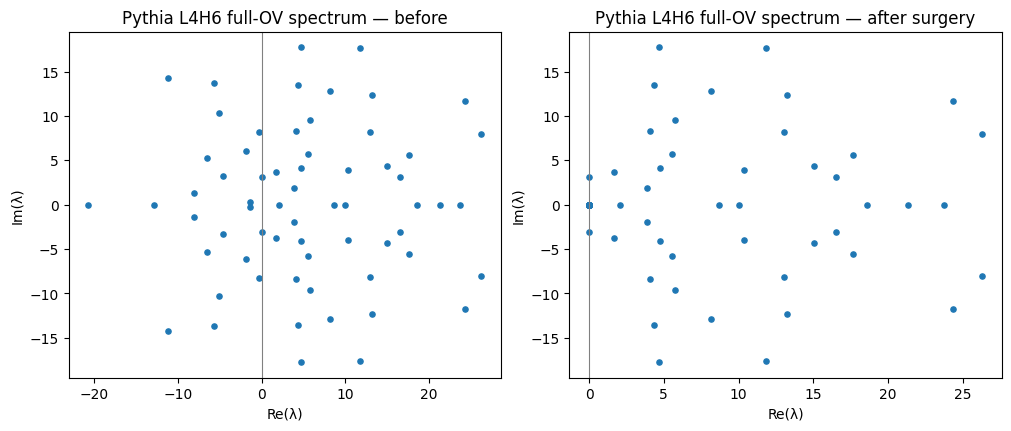

In [11]:
l, h = IND["pythia"]
W_V_orig = pythia.blocks[l].attn.W_V.data[h].clone()   # snapshot: this cell must be re-runnable


def full_ov_eigs(model, l, h):
    small = ((model.W_O[l, h] @ model.W_U) @ (model.W_E @ model.W_V[l, h])).float()
    return torch.linalg.eig(small)


def copying_score(eigs):
    return (eigs.real.sum() / eigs.abs().sum()).item()


eigs, V = full_ov_eigs(pythia, l, h)
keep = eigs.real > 0
P = V @ torch.diag(keep.to(V.dtype)) @ torch.linalg.inv(V)
SURGERY = {
    "cond": torch.linalg.cond(V).item(),
    "imag_residual": P.imag.abs().max().item(),
    "score_before": copying_score(eigs),
    "frac_pos_before": keep.float().mean().item(),
    "gap_before": BASE["pythia"]["gap"],
    "nat_before": pythia(NAT["pythia"], return_type="loss").item(),
}
print(f"projector: cond(V)={SURGERY['cond']:.1f}  max|Im(P)|={SURGERY['imag_residual']:.2e}"
      f"  -> keeping {int(keep.sum())}/{len(keep)} eigendirections")

pythia.blocks[l].attn.W_V.data[h] = (W_V_orig.float() @ P.real).to(W_V_orig.dtype)

eigs_after = torch.linalg.eigvals(
    ((pythia.W_O[l, h] @ pythia.W_U) @ (pythia.W_E @ pythia.W_V[l, h])).float()
)
lpt = pythia(TOKENS["pythia"], return_type="loss", loss_per_token=True)
SURGERY.update({
    "score_after": copying_score(eigs_after),
    "frac_pos_after": (eigs_after.real > 0).float().mean().item(),
    "gap_after": loss_gap(lpt),
    "nat_after": pythia(NAT["pythia"], return_type="loss").item(),
})

pythia.blocks[l].attn.W_V.data[h] = W_V_orig            # restore
_restored = loss_gap(pythia(TOKENS["pythia"], return_type="loss", loss_per_token=True))

print(f"copying score   {SURGERY['score_before']:.3f} -> {SURGERY['score_after']:.3f}"
      f"   ({SURGERY['frac_pos_before']:.0%} -> {SURGERY['frac_pos_after']:.0%} positive)")
print(f"induction gap   {SURGERY['gap_before']:.3f} -> {SURGERY['gap_after']:.3f} nats"
      f"   ({(SURGERY['gap_after'] - SURGERY['gap_before']) / SURGERY['gap_before']:+.1%})")
print(f"natural loss    {SURGERY['nat_before']:.3f} -> {SURGERY['nat_after']:.3f} nats"
      f"   ({(SURGERY['nat_after'] - SURGERY['nat_before']) / SURGERY['nat_before']:+.1%})")
print(f"restored gap    {_restored:.3f}  (matches clean {BASE['pythia']['gap']:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), constrained_layout=True)
for ax, (e, title) in zip(axes, [(eigs, "before"), (eigs_after, "after surgery")]):
    ax.scatter(e.real.cpu().detach(), e.imag.cpu().detach(), s=14)
    ax.axvline(0, color="grey", lw=0.8)
    ax.set_title(f"Pythia L{l}H{h} full-OV spectrum — {title}")
    ax.set_xlabel("Re(\u03bb)")
    ax.set_ylabel("Im(\u03bb)")
plt.show()

### Results — Act 5: H3 is not confirmed

The surgery is numerically sound. `cond(V) = 73.9` — well-conditioned, no defective-matrix blow-up — and the projector's largest imaginary component is `2.4e-06`, confirming in measurement what the conjugate-pair argument predicts on paper. Restoring the snapshot returns the gap to 17.881 exactly. Whatever the numbers below mean, they are not an artefact of a broken reconstruction.

**The edit does what it says.** Keeping 44 of 64 eigendirections lifts the copying score **0.423 → 0.759**, and the positive share **69% → 86%**. The spectrum plot shows the left half of the cloud gone.

**And the prediction fails.** H3 said: remove the non-copying directions and induction should be *preserved or improved* while the damage lands elsewhere. Measured:

| | before | after | change |
|---|---|---|---|
| induction loss gap | 17.881 | 16.848 | **−5.8%** |
| natural-text loss | 2.741 | 2.746 | +0.2% |

Induction got **worse**, not better. And the asymmetry runs the wrong way: in relative terms the purified head loses about 29 times more on the synthetic induction task than on natural text. The directions we deleted as "not copying" were contributing to induction *more* than to anything else the head does.

So the superposition story survives only in its weakest form. It is true that L4H6's OV does more than copy. It is **not** true that copying and the other work occupy separable halves of the spectrum, with the sign of the real part as the seam. Whatever those 20 negative-real-part directions are doing, induction needs them. A head that scores better on the copying metric is a worse induction head — which is a warning about the metric as much as about the head.

**Why 0.759 and not 1.000.** We removed every negative eigendirection, so why does the score stop three-quarters of the way? Because the dropped directions are cleanly gone — their eigenvalues sit at ~1e-06 against a kept maximum of ~27 — and what remains between 0.759 and 1.0 is not negative mass at all. It is **imaginary** mass. The copying score is `Σ Re(λ) / Σ |λ|`, and for a complex eigenvalue `λ = a + bi` with `a > 0`, `|λ| = √(a² + b²) > a`. Every eigenvalue with an imaginary part drags the ratio below 1 no matter how positive its real part is, and only a spectrum that is *positive and real* — the toy's `I×4` — reaches 1.000.

That is a fact about what the copying score measures. The toy's OV was a pure scaling: it took a token's direction and pushed it back out along itself. A real head's OV **rotates** as well as scales, and rotation is exactly the imaginary part. "Positive real part" and "pure copier" are different edits, and this act only ever performed the first one. The remaining gap to the toy is not dilution to be cleaned away; it is the head doing something the toy has no vocabulary for.

The act is a stretch and it ends on a negative, which is the result: the sign of the real part is the wrong knife for separating a head's jobs.

## Act 6 — Verdict

Every intervention in the notebook, scored as the fraction of each model's own induction loss gap it destroyed.

In [12]:
import pandas as pd

rows = []
for name in MODELS:
    li, hi = IND[name]
    lp, hp = PREV[name]
    rows.append({
        "model": name,
        "clean gap (nats)": f"{BASE[name]['gap']:.2f}",
        "ablate induction head": f"L{li}H{hi}: {LADDER[name]['top-1']:.1%}",
        "ablate top-3 heads": f"{LADDER[name]['top-3']:.1%}",
        "ablate whole cluster": f"n={len(CLUSTER[name])}: {LADDER[name]['cluster']:.1%}",
        "ablate prev-token head": f"L{lp}H{hp}: {MED[name]['collapse']:.1%}",
        "induction stripe, feeder cut": f"{MED[name]['stripe_clean']:.2f} -> {MED[name]['stripe_abl']:.2f}",
        "matched logit, feeder cut": f"{DLA[name]['clean']:+.2f} -> {DLA[name]['feeder_ablated']:+.2f}",
        "natural text (rep.bigram / else)": f"{NATDELTA[name]['repeated']:+.2f} / {NATDELTA[name]['elsewhere']:+.2f}",
    })
verdict = pd.DataFrame(rows).set_index("model")
display(verdict.T)

model,gpt2,pythia
clean gap (nats),12.71,17.88
ablate induction head,L5H5: 0.7%,L4H6: 4.8%
ablate top-3 heads,20.7%,9.2%
ablate whole cluster,n=18: 82.2%,n=22: 86.3%
ablate prev-token head,L4H11: 2.3%,L3H2: 43.9%
"induction stripe, feeder cut",0.93 -> 0.64,0.99 -> 0.16
"matched logit, feeder cut",+4.77 -> +3.39,+0.93 -> +0.17
natural text (rep.bigram / else),+1.24 / +0.18,+0.61 / +0.17


## Honest gaps, and the answer to the blog's promise

**The promise, answered.** The previous post said: *knock out L4H11 and L5H5, or L3H2 and L4H6, and watch whether the induction score collapses.* It does not. Mean-ablating the single best induction head destroys **0.7%** of GPT-2's induction behavior and **4.8%** of Pythia's. These are the right heads — found by argmax, matching the heads Wang et al. name in print, scoring 0.930 and 0.987 on the diagnostic. Deleting them changes almost nothing. The notebook's central hypothesis, in the form it was posed, is false.

**What was actually there.** Induction is not a head, it is a **population**. GPT-2 runs 18 heads above the 0.2 gate and Pythia 22, and the behavior does not fall over until the whole population goes (**82.2%** and **86.3%**). Even the top three — all scoring ≥0.9 — buy only 20.7% and 9.2%. When L5H5 is cut, its twin L6H9 does step up (0.917 → 0.963), the backup-head effect Wang et al. describe; but the step is small, and dynamic compensation is the lesser half of the explanation. The greater half is that the job was already sprayed across a dozen heads before anything was touched.

**What ablation actually measures.** The sharpest result is the one the design did not predict. Cutting Pythia's *previous-token* head — the feeder, one layer upstream, which the induction head is structurally untouched by — destroys **43.9%** of its induction behavior, nine times more than cutting the "induction head" itself, along with 83.9% of the untouched downstream head's attention stripe and 82.2% of its push on the matched logit. GPT-2 degrades gently on the same cut (2.3%) for the reason Pythia does not: its previous-token job is backed up (L2H2 at 0.485) and Pythia's L3H2 has no twin at all.

So the size of an ablation effect tracks **how redundant a component is, not how important it is**. A head can be doing essential work and register 0.7% because seventeen others do it too; a head can be a single point of failure and register 44% while never appearing in the circuit's name. *"Ablate it and see if it matters"* silently asks a different question than the one it appears to ask. That is the notebook's finding, and it is a caution about the method, not a fact about these two models.

**What did reproduce, causally.** The previous notebook's rank-1 K-composition claim survives the transition from correlation to cause in both models: cutting the feeder degrades the untouched induction head's attention (0.930 → 0.638; 0.987 → 0.159) and its logit push (+4.77 → +3.39; +0.93 → +0.17) together, in proportion. The wiring is real. And Act 4 shows the cluster is doing induction rather than holding the network together: on Pile text its removal costs 6.9× (GPT-2) and 3.6× (Pythia) more where a bigram has recurred than elsewhere.

**Named limitations.**

- **The 82% is not purely induction.** Act 4's "elsewhere" damage is small but nonzero (+0.18 / +0.17 nats), so some of the cluster-ablation collapse is the generic harm of removing a quarter of the network's heads. The ratio supports a comparative claim, not a clean decomposition.
- **The cluster is an artefact of a threshold.** Membership comes from an attention score clearing 0.2 — an inherited convention, not a principled boundary. The 18/22 head counts, and therefore the 82%/86%, move with that number.
- **Mean-ablation is one ablation family.** Replacing a head with its mean removes its signal but not its presence. Resample ablation (substituting another sequence's activations) removes different information and can give different answers; nothing here distinguishes them.
- **The hydra check measures attention, not output.** L6H9 attends 0.046 more to the matched position under ablation. Whether it *writes* more of the right token is a DLA question this act does not ask.
- **Bigram recurrence is a permissive proxy.** It marks where induction *could* act, not where it did — common English bigrams recur constantly with nothing being copied — which dilutes Act 4's ratios downward.
- **Act 5's negative is narrow.** It refutes "positive/negative real part separates copying from other work" for one head in one model. It does not refute superposition, and the copying score's imaginary-mass ceiling means the toy's 1.000 was never a reachable target for a head that rotates.
- **Everything is single-seed and small.** One 32×101 synthetic batch, eight 256-token Pile documents, two models, no error bars. DLA ignores the final LayerNorm scale. The composed-weight caveats from the previous notebook (folded LayerNorm, dropped biases, RoPE ignored in static weight products) still apply to Act 5's spectrum.
- **No path patching.** Act 3 shows the feeder matters; it does not map the route. Cutting one edge is not the same as tracing the graph.

**Handoff.** Two rungs follow from this. **Path patching** (Wang et al.'s method) would replace the single-edge cut with the actual causal graph, and would say whether the feeder's effect travels the K-composition route we think it does or arrives some other way. **Resample ablation** would separate "this head's information" from "this head's presence" — the distinction mean-ablation cannot draw. And the redundancy result suggests its own experiment: if 18 heads share one job, ablate them in every order and watch where the curve bends, rather than assuming the population is uniform.